# インポート

In [30]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import pytesseract

読み込んだ画像を表示


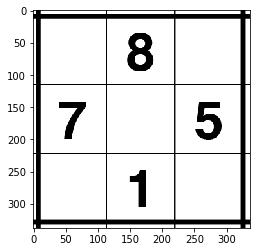

In [31]:
image_path = "./sample_data/image01_c1.png"

img = cv2.imread(image_path)
print("読み込んだ画像を表示")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))



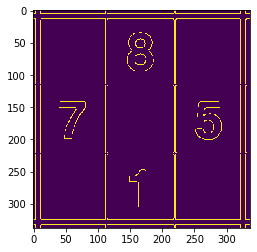

In [32]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,50,150,apertureSize = 3)
cv2.imwrite('./tmp/edges.jpg', edges)
plt.imshow(edges)



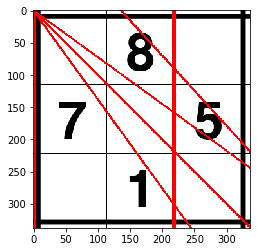

In [52]:
lines = cv2.HoughLines(edges,1,np.pi/180,200)
for rho,theta in lines[0]:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))

    cv2.line(img,(x1,y1),(x2,y2),(0,0,255),2)

cv2.imwrite('./tmp/houghlines.jpg',img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))